In [ ]:
"""

# Project Title
Agentic text-to-SQL system with ReAct, LangChain and LangGraph

# Project Overview:
Before the adoption of Large Language Models (LLMs) and Agentic AI, querying databases demanded strong SQL knowledge, making an obstacle for
non-technical users as well as business professionals.  With the utilization of LLMs and Agentic AI in the IT industry, both technical and non-technical
 users can now use Agent powered systems that think, decide, and execute with various tools to extract Informative data.

This project highlights an end-to-end Text-to-SQL Agentic AI system that transforms natural language queries into SQL statements, implements them on
a real database, and then yields error-free, human-readable information. The system incorporates the ReAct platform, facilitating the agent to perform
logical deduction step-by-step, and then choose which tools to use to automatically refine results.

# Aim:
The main objective of this project is to make an Agentic Text-to-SQL pipeline. Finally, we need to use it. It supports the following things:

•	Change NLP (queries) into SQL expressions.
•	Carry out real-time visibility into essential steps
•	Use tools to connect with a SQL database.
•	Apply many steps to get final answer using ReAct oriented approach
•	Generate usable output

# Technical Components:
•	Google Colab with Python environment
•	LangChain
•	LangGraph with ReAct Agent architecture
•	OpenAI with LLM
•	SQLite Database with tools
•	Prompt tuning
•	Agentic AI framework

# Notable Features:
•	Fully agentic work
•	End to end Text to SQL workflow
•	Tool focused system
•	 ReAct logic framework
•	Live database querying
•	 Visualization for Agent thought flow
•	Real-time agent outputs
•	SQL query evaluation
•	Executable SQL query templates



"""

# install all necessary libraries for AI


In [ ]:
!pip install langchain-core==0.2.43

In [ ]:
!pip install langchain-community==0.2.17

In [ ]:
!pip install langchain-openai==0.1.23

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 19.8 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.12.0
    Uninstalling openai-2.12.0:
      Successfully uninstalled openai-2.12.0


In [ ]:
!pip install langgraph==0.2.41

In [ ]:
import os

In [ ]:
from getpass import getpass

In [ ]:
# Give an OpenAI API key
os.environ['OPENAI_API_KEY'] = getpass('put OpenAI API key: ')

put OpenAI API key: ··········


# Preparing Structured Query Language (SQL) Database Environment

In [ ]:
# Access for comicdb database
!gdown 16mZm3C7xKpPqp_86e64uzduLpM5mPUdq


Downloading...
From: https://drive.google.com/uc?id=16mZm3C7xKpPqp_86e64uzduLpM5mPUdq
To: /content/comicdb_create_script.sql
100% 14.5k/14.5k [00:00<00:00, 42.7MB/s]


# As sqlite3 is accessible, we can generate comicdb(comic store).

In [ ]:
import sqlite3

# Conform whether sqlite is installed.
print(sqlite3.sqlite_version)

3.37.2


In [ ]:
# Construct the somic store database
comicdb = 'comic_store.db'

sql_table = 'comicdb_create_script.sql'

comic_store_database_connection = sqlite3.connect(comicdb)

with open(sql_table, 'r') as sqlt:
    comic_store_database_connection.executescript(sqlt.read())

comic_store_database_connection.close()


In [ ]:


# Open connection
comic_store_database_connection = sqlite3.connect(comicdb)

# sqlite_master in SQLite holds schema objects such as tables, indexes, views, and triggers
# We only want table names
comic_store_database_cursor = comic_store_database_connection.cursor()

# Execute SQL query
comic_store_database_cursor.execute(
    "SELECT name FROM sqlite_master WHERE type='table';"
)

# table names
schema_tables = [table_entry[0] for table_entry in comic_store_database_cursor.fetchall()]

# Need to close comic store database connection to prevent resource leaks with avoiding unexpected errors
comic_store_database_connection.close()  # key step

schema_tables


['Branch',
 'Employee',
 'Publisher',
 'Comic',
 'Inventory',
 'Customer',
 'Sale',
 'SaleTransactions']

In [ ]:
# Comic Data

import pandas as pd

comic_store_database_connection_comic = sqlite3.connect(comicdb)

comic_data = pd.read_sql_query('''SELECT * FROM Comic LIMIT 7;''', comic_store_database_connection_comic)

comic_store_database_connection_comic.close()

comic_data

,ComicId,Title,PublisherId,Genre,Price,ReleaseDate
0,1,Spider-Man: Homecoming,1,Superhero,19.99,2017-07-07
1,2,Batman: Year One,2,Superhero,14.99,1987-02-01
2,3,Hellboy: Seed of Destruction,3,Supernatural,24.99,1994-10-01
3,4,Saga Volume 1,4,Fantasy,12.99,2012-03-14
4,5,Transformers: All Hail Megatron,5,Science Fiction,25.99,2008-09-01
5,6,X-Men: Days of Future Past,1,Superhero,18.99,1981-01-01
6,7,The Killing Joke,2,Superhero,14.99,1988-03-29


# Comic store database initialization

In [ ]:
# load SQLDatabase
from langchain_community.utilities import SQLDatabase

# Load database instance
comicstore_db = SQLDatabase.from_uri('sqlite:///comic_store.db')

# List tables
print('List of database tables:', comicstore_db.get_usable_table_names())

List of database tables: ['Branch', 'Comic', 'Customer', 'Employee', 'Inventory', 'Publisher', 'Sale', 'SaleTransactions']


In [ ]:
# View comic table columns
comicstore_db.get_table_info(table_names = ['Comic'])

'\nCREATE TABLE "Comic" (\n\t"ComicId" INTEGER NOT NULL, \n\t"Title" NVARCHAR(100) NOT NULL, \n\t"PublisherId" INTEGER NOT NULL, \n\t"Genre" NVARCHAR(50), \n\t"Price" NUMERIC(10, 2) NOT NULL, \n\t"ReleaseDate" DATETIME, \n\tPRIMARY KEY ("ComicId"), \n\tFOREIGN KEY("PublisherId") REFERENCES "Publisher" ("PublisherId")\n)\n\n/*\n3 rows from Comic table:\nComicId\tTitle\tPublisherId\tGenre\tPrice\tReleaseDate\n1\tSpider-Man: Homecoming\t1\tSuperhero\t19.99\t2017-07-07 00:00:00\n2\tBatman: Year One\t2\tSuperhero\t14.99\t1987-02-01 00:00:00\n3\tHellboy: Seed of Destruction\t3\tSupernatural\t24.99\t1994-10-01 00:00:00\n*/'

In [ ]:
print('View first 7 rows in Comic table:')
comicstore_db.run('SELECT * FROM Comic LIMIT 7;', include_columns = True)

View first 7 rows in Comic table:


"[{'ComicId': 1, 'Title': 'Spider-Man: Homecoming', 'PublisherId': 1, 'Genre': 'Superhero', 'Price': 19.99, 'ReleaseDate': '2017-07-07'}, {'ComicId': 2, 'Title': 'Batman: Year One', 'PublisherId': 2, 'Genre': 'Superhero', 'Price': 14.99, 'ReleaseDate': '1987-02-01'}, {'ComicId': 3, 'Title': 'Hellboy: Seed of Destruction', 'PublisherId': 3, 'Genre': 'Supernatural', 'Price': 24.99, 'ReleaseDate': '1994-10-01'}, {'ComicId': 4, 'Title': 'Saga Volume 1', 'PublisherId': 4, 'Genre': 'Fantasy', 'Price': 12.99, 'ReleaseDate': '2012-03-14'}, {'ComicId': 5, 'Title': 'Transformers: All Hail Megatron', 'PublisherId': 5, 'Genre': 'Science Fiction', 'Price': 25.99, 'ReleaseDate': '2008-09-01'}, {'ComicId': 6, 'Title': 'X-Men: Days of Future Past', 'PublisherId': 1, 'Genre': 'Superhero', 'Price': 18.99, 'ReleaseDate': '1981-01-01'}, {'ComicId': 7, 'Title': 'The Killing Joke', 'PublisherId': 2, 'Genre': 'Superhero', 'Price': 14.99, 'ReleaseDate': '1988-03-29'}]"

In [ ]:
comicstore_db.run('SELECT * FROM Branch LIMIT 1;', include_columns = True)      # see one row only

"[{'BranchId': 1, 'Name': 'Central Comics', 'City': 'New York', 'State': 'NY', 'Country': 'USA', 'PostalCode': '10001'}]"

In [ ]:
print('View first 7 rows in Employee table:')
comicstore_db.run('SELECT * FROM Employee LIMIT 7;', include_columns = True)

View first 7 rows in Employee table:


"[{'EmployeeId': 1, 'FirstName': 'John', 'LastName': 'Doe', 'Title': 'Manager', 'BranchId': 1, 'HireDate': '2015-06-01', 'Email': 'john.doe@comicstore.com', 'Phone': '555-1234'}, {'EmployeeId': 2, 'FirstName': 'Jane', 'LastName': 'Smith', 'Title': 'Sales Associate', 'BranchId': 1, 'HireDate': '2017-09-15', 'Email': 'jane.smith@comicstore.com', 'Phone': '555-5678'}, {'EmployeeId': 3, 'FirstName': 'Alice', 'LastName': 'Brown', 'Title': 'Sales Associate', 'BranchId': 2, 'HireDate': '2018-03-12', 'Email': 'alice.brown@comicstore.com', 'Phone': '555-9876'}, {'EmployeeId': 4, 'FirstName': 'Michael', 'LastName': 'Clark', 'Title': 'Manager', 'BranchId': 2, 'HireDate': '2016-02-20', 'Email': 'michael.clark@comicstore.com', 'Phone': '555-6543'}, {'EmployeeId': 5, 'FirstName': 'Emily', 'LastName': 'White', 'Title': 'Sales Associate', 'BranchId': 3, 'HireDate': '2019-07-10', 'Email': 'emily.white@comicstore.com', 'Phone': '555-4321'}]"

In [ ]:
print('View first 3 rows in Employee table:')
comicstore_db.run('SELECT EmployeeId, LastName, Title, BranchId FROM Employee LIMIT 3;', include_columns = True)

View first 3 rows in Employee table:


"[{'EmployeeId': 1, 'LastName': 'Doe', 'Title': 'Manager', 'BranchId': 1}, {'EmployeeId': 2, 'LastName': 'Smith', 'Title': 'Sales Associate', 'BranchId': 1}, {'EmployeeId': 3, 'LastName': 'Brown', 'Title': 'Sales Associate', 'BranchId': 2}]"

In [ ]:
print('View first 7 rows in Sale table:')
comicstore_db.run('SELECT * FROM Sale LIMIT 7;', include_columns = True)

View first 7 rows in Sale table:


"[{'SaleId': 1, 'CustomerId': 1, 'EmployeeId': 1, 'SaleDate': '2023-01-15', 'TotalAmount': 54.97}, {'SaleId': 2, 'CustomerId': 2, 'EmployeeId': 2, 'SaleDate': '2023-01-20', 'TotalAmount': 49.97}, {'SaleId': 3, 'CustomerId': 3, 'EmployeeId': 3, 'SaleDate': '2023-01-25', 'TotalAmount': 59.97}, {'SaleId': 4, 'CustomerId': 4, 'EmployeeId': 4, 'SaleDate': '2023-01-30', 'TotalAmount': 45.98}, {'SaleId': 5, 'CustomerId': 5, 'EmployeeId': 5, 'SaleDate': '2023-02-05', 'TotalAmount': 29.97}, {'SaleId': 6, 'CustomerId': 6, 'EmployeeId': 1, 'SaleDate': '2023-02-10', 'TotalAmount': 74.97}, {'SaleId': 7, 'CustomerId': 7, 'EmployeeId': 2, 'SaleDate': '2023-02-15', 'TotalAmount': 64.97}]"

In [ ]:
print('View first 3 rows in Sale table:')
comicstore_db.run('SELECT SaleId,  EmployeeId FROM Sale LIMIT 3;', include_columns = True)

View first 3 rows in Sale table:


"[{'SaleId': 1, 'EmployeeId': 1}, {'SaleId': 2, 'EmployeeId': 2}, {'SaleId': 3, 'EmployeeId': 3}]"

In [ ]:
print('View first 3 rows in Sale table:')
comicstore_db.run('SELECT SaleId,  EmployeeId, TotalAmount FROM Sale LIMIT 3')     # do not include columns names.

View first 3 rows in Sale table:


'[(1, 1, 54.97), (2, 2, 49.97), (3, 3, 59.97)]'

In [ ]:
print(comicstore_db.get_table_info(['Comic']))


CREATE TABLE "Comic" (
	"ComicId" INTEGER NOT NULL, 
	"Title" NVARCHAR(100) NOT NULL, 
	"PublisherId" INTEGER NOT NULL, 
	"Genre" NVARCHAR(50), 
	"Price" NUMERIC(10, 2) NOT NULL, 
	"ReleaseDate" DATETIME, 
	PRIMARY KEY ("ComicId"), 
	FOREIGN KEY("PublisherId") REFERENCES "Publisher" ("PublisherId")
)

/*
3 rows from Comic table:
ComicId	Title	PublisherId	Genre	Price	ReleaseDate
1	Spider-Man: Homecoming	1	Superhero	19.99	2017-07-07 00:00:00
2	Batman: Year One	2	Superhero	14.99	1987-02-01 00:00:00
3	Hellboy: Seed of Destruction	3	Supernatural	24.99	1994-10-01 00:00:00
*/


In [ ]:
print(comicstore_db.get_table_info(['Sale']))


CREATE TABLE "Sale" (
	"SaleId" INTEGER NOT NULL, 
	"CustomerId" INTEGER NOT NULL, 
	"EmployeeId" INTEGER, 
	"SaleDate" DATETIME NOT NULL, 
	"TotalAmount" NUMERIC(10, 2) NOT NULL, 
	PRIMARY KEY ("SaleId"), 
	FOREIGN KEY("EmployeeId") REFERENCES "Employee" ("EmployeeId"), 
	FOREIGN KEY("CustomerId") REFERENCES "Customer" ("CustomerId")
)

/*
3 rows from Sale table:
SaleId	CustomerId	EmployeeId	SaleDate	TotalAmount
1	1	1	2023-01-15 00:00:00	54.97
2	2	2	2023-01-20 00:00:00	49.97
3	3	3	2023-01-25 00:00:00	59.97
*/


# Prepare SQL tools

In [ ]:
from langchain_openai import ChatOpenAI

# Initializing gpt model
chatopenai_gpt = ChatOpenAI(model = 'gpt-4o', temperature=0)

In [ ]:
# Get tools
from langchain_community.agent_toolkits import SQLDatabaseToolkit

sqldatabase_toolkit = SQLDatabaseToolkit(llm = chatopenai_gpt, db = comicstore_db)
sql_list_tools = sqldatabase_toolkit.get_tools()
sql_list_tools

[QuerySQLDataBaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7b29a653ac60>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7b29a653ac60>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7b29a653ac60>),
 QuerySQLCheckerTool(description='Use this tool to double check

In [ ]:
# list tools
for agent_tool in sql_list_tools:
    print(agent_tool.name, ':', agent_tool.description)


sql_db_query : Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.
sql_db_schema : Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3
sql_db_list_tables : Input is an empty string, output is a comma-separated list of tables in the database.
sql_db_query_checker : Use this tool to double check if your query is correct before executing it. Always use this tool before executing a query with sql_db_query!


# ReAct agent guidance prompt


In [ ]:
from langchain_core.messages import SystemMessage

In [ ]:
agent_guidelines = '''
You are responsible AI agent, Your main job is  to  get SQL queries from input plain text.

Given an input query from the user:
- First, you need to review the database schema tables.
- As a SQLite agent, you can easily change plain text questions into SQL queries.
- As necessary, you can check the required table schemes.
- You can write a SQLite SELECT query with text.
- You must limit query results to 7 rows.
- You do not have right to pick non-essential columns.
- Organize output if it improves understandability.

Agent instructions:
- Apply only the provided SQL tools
- Always verify query correctness to
- Drop errors if you examine query correctness first
- If your execution fails, you should rewrite the query and perform again.
- Your operations should be read only. You are not responsible for changing the database with DROP, UPDATE, INSERT, DELETE.
- Provide results only.   I do not need your SQL database explanations.

Output instructions:
- Use markdown to show the output with markdown
- Correct special symbols such as $ → \\$ correctly to prevent errors.
'''

In [ ]:
system_message = SystemMessage(content = agent_guidelines)
system_message

SystemMessage(content='\nYou are responsible AI agent, Your main job is  to  get SQL queries from input plain text.\n\nGiven an input query from the user:\n- First, you need to review the database schema tables.\n- As a SQLite agent, you can easily change plain text questions into SQL queries.\n- As necessary, you can check the required table schemes.\n- You can write a SQLite SELECT query with text.\n- You must limit query results to 7 rows.\n- You do not have right to pick non-essential columns.\n- Organize output if it improves understandability.\n\nAgent instructions:\n- Apply only the provided SQL tools\n- Always verify query correctness to\n- Drop errors if you examine query correctness first\n- If your execution fails, you should rewrite the query and perform again.\n- Your operations should be read only. You are not responsible for changing the database with DROP, UPDATE, INSERT, DELETE.\n- Provide results only.   I do not need your SQL database explanations.\n\nOutput instruct

# Engineering end-to-end text-to-SQL ReAct Agent

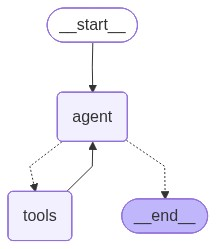

In [ ]:
# Create the ReAct Agent

from langgraph.prebuilt import create_react_agent

# Do not rename for state_modifier, tools, or model. There are some valid reasons.
sql_agent = create_react_agent(model = chatopenai_gpt, state_modifier = system_message,  tools = sql_list_tools)
sql_agent

from IPython.display import Image, display

# Explore the ReAct agent thought process
sql_agent_graph = sql_agent.get_graph()
sql_agent_graph_png = sql_agent_graph.draw_mermaid_png()
display(Image(sql_agent_graph_png))


In [ ]:
# Check sql_agent status using some examples

In [ ]:
from langchain_core.messages import HumanMessage

In [ ]:
query = 'What are the top 5 highest selling comics?'

from IPython.display import display, Markdown

for response in sql_agent.stream({'messages': [HumanMessage(content = query )]}):
    display(Markdown(str(response)))

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_8BUfbQqhAdMW5tIxkCbBS1VJ', 'function': {'arguments': '{}', 'name': 'sql_db_list_tables'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 553, 'total_tokens': 565, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-62d6be4e-04bd-4c77-a435-5972adce3c17-0', tool_calls=[{'name': 'sql_db_list_tables', 'args': {}, 'id': 'call_8BUfbQqhAdMW5tIxkCbBS1VJ', 'type': 'tool_call'}], usage_metadata={'input_tokens': 553, 'output_tokens': 12, 'total_tokens': 565})]}}

{'tools': {'messages': [ToolMessage(content='Branch, Comic, Customer, Employee, Inventory, Publisher, Sale, SaleTransactions', name='sql_db_list_tables', id='83021b7e-0555-424c-9421-b2ef2051da88', tool_call_id='call_8BUfbQqhAdMW5tIxkCbBS1VJ')]}}

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_CLvOPRY1IYs8QmqadJefEiaX', 'function': {'arguments': '{"table_names":"Comic, Sale, SaleTransactions"}', 'name': 'sql_db_schema'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 591, 'total_tokens': 612, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-f706a884-1d1a-4454-9555-9007ed93b8a4-0', tool_calls=[{'name': 'sql_db_schema', 'args': {'table_names': 'Comic, Sale, SaleTransactions'}, 'id': 'call_CLvOPRY1IYs8QmqadJefEiaX', 'type': 'tool_call'}], usage_metadata={'input_tokens': 591, 'output_tokens': 21, 'total_tokens': 612})]}}

{'tools': {'messages': [ToolMessage(content='\nCREATE TABLE "Comic" (\n\t"ComicId" INTEGER NOT NULL, \n\t"Title" NVARCHAR(100) NOT NULL, \n\t"PublisherId" INTEGER NOT NULL, \n\t"Genre" NVARCHAR(50), \n\t"Price" NUMERIC(10, 2) NOT NULL, \n\t"ReleaseDate" DATETIME, \n\tPRIMARY KEY ("ComicId"), \n\tFOREIGN KEY("PublisherId") REFERENCES "Publisher" ("PublisherId")\n)\n\n/*\n3 rows from Comic table:\nComicId\tTitle\tPublisherId\tGenre\tPrice\tReleaseDate\n1\tSpider-Man: Homecoming\t1\tSuperhero\t19.99\t2017-07-07 00:00:00\n2\tBatman: Year One\t2\tSuperhero\t14.99\t1987-02-01 00:00:00\n3\tHellboy: Seed of Destruction\t3\tSupernatural\t24.99\t1994-10-01 00:00:00\n*/\n\n\nCREATE TABLE "Sale" (\n\t"SaleId" INTEGER NOT NULL, \n\t"CustomerId" INTEGER NOT NULL, \n\t"EmployeeId" INTEGER, \n\t"SaleDate" DATETIME NOT NULL, \n\t"TotalAmount" NUMERIC(10, 2) NOT NULL, \n\tPRIMARY KEY ("SaleId"), \n\tFOREIGN KEY("EmployeeId") REFERENCES "Employee" ("EmployeeId"), \n\tFOREIGN KEY("CustomerId") REFERENCES "Customer" ("CustomerId")\n)\n\n/*\n3 rows from Sale table:\nSaleId\tCustomerId\tEmployeeId\tSaleDate\tTotalAmount\n1\t1\t1\t2023-01-15 00:00:00\t54.97\n2\t2\t2\t2023-01-20 00:00:00\t49.97\n3\t3\t3\t2023-01-25 00:00:00\t59.97\n*/\n\n\nCREATE TABLE "SaleTransactions" (\n\t"TransactionId" INTEGER NOT NULL, \n\t"SaleId" INTEGER NOT NULL, \n\t"ComicId" INTEGER NOT NULL, \n\t"Quantity" INTEGER NOT NULL, \n\t"Price" NUMERIC(10, 2) NOT NULL, \n\tPRIMARY KEY ("TransactionId"), \n\tFOREIGN KEY("ComicId") REFERENCES "Comic" ("ComicId"), \n\tFOREIGN KEY("SaleId") REFERENCES "Sale" ("SaleId")\n)\n\n/*\n3 rows from SaleTransactions table:\nTransactionId\tSaleId\tComicId\tQuantity\tPrice\n1\t1\t1\t1\t19.99\n2\t1\t2\t2\t14.99\n3\t2\t3\t1\t24.99\n*/', name='sql_db_schema', id='6872bd36-1f32-4f2d-a016-3075eaae525c', tool_call_id='call_CLvOPRY1IYs8QmqadJefEiaX')]}}

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_jN4DcaKPow07rMXwyHZrZzi0', 'function': {'arguments': '{"query":"SELECT c.Title, SUM(st.Quantity) as TotalSold \\nFROM Comic c \\nJOIN SaleTransactions st ON c.ComicId = st.ComicId \\nGROUP BY c.Title \\nORDER BY TotalSold DESC \\nLIMIT 5;"}', 'name': 'sql_db_query_checker'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 1194, 'total_tokens': 1260, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-ac698d38-2ef8-4991-9512-f2fbb8cc7954-0', tool_calls=[{'name': 'sql_db_query_checker', 'args': {'query': 'SELECT c.Title, SUM(st.Quantity) as TotalSold \nFROM Comic c \nJOIN SaleTransactions st ON c.ComicId = st.ComicId \nGROUP BY c.Title \nORDER BY TotalSold DESC \nLIMIT 5;'}, 'id': 'call_jN4DcaKPow07rMXwyHZrZzi0', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1194, 'output_tokens': 66, 'total_tokens': 1260})]}}

{'tools': {'messages': [ToolMessage(content='```sql\nSELECT c.Title, SUM(st.Quantity) as TotalSold \nFROM Comic c \nJOIN SaleTransactions st ON c.ComicId = st.ComicId \nGROUP BY c.Title \nORDER BY TotalSold DESC \nLIMIT 5;\n```', name='sql_db_query_checker', id='a554eda8-fc25-4a38-aa14-b4afdf316f7e', tool_call_id='call_jN4DcaKPow07rMXwyHZrZzi0')]}}

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_Ges0LxrmC1kWRtvmSHKcjtei', 'function': {'arguments': '{"query":"SELECT c.Title, SUM(st.Quantity) as TotalSold \\nFROM Comic c \\nJOIN SaleTransactions st ON c.ComicId = st.ComicId \\nGROUP BY c.Title \\nORDER BY TotalSold DESC \\nLIMIT 5;"}', 'name': 'sql_db_query'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 1320, 'total_tokens': 1385, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-8d2a3e7e-c4a7-4e3e-81b2-39eba099e618-0', tool_calls=[{'name': 'sql_db_query', 'args': {'query': 'SELECT c.Title, SUM(st.Quantity) as TotalSold \nFROM Comic c \nJOIN SaleTransactions st ON c.ComicId = st.ComicId \nGROUP BY c.Title \nORDER BY TotalSold DESC \nLIMIT 5;'}, 'id': 'call_Ges0LxrmC1kWRtvmSHKcjtei', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1320, 'output_tokens': 65, 'total_tokens': 1385})]}}

{'tools': {'messages': [ToolMessage(content="[('Wolverine: Old Man Logan', 3), ('V for Vendetta', 2), ('Usagi Yojimbo Volume 1', 2), ('Transformers: All Hail Megatron', 2), ('The Killing Joke', 2)]", name='sql_db_query', id='b9c4d377-b961-4eb6-97e1-a1578b9824b2', tool_call_id='call_Ges0LxrmC1kWRtvmSHKcjtei')]}}

{'agent': {'messages': [AIMessage(content='Here are the top 5 highest selling comics:\n\n1. **Wolverine: Old Man Logan** - 3 copies sold\n2. **V for Vendetta** - 2 copies sold\n3. **Usagi Yojimbo Volume 1** - 2 copies sold\n4. **Transformers: All Hail Megatron** - 2 copies sold\n5. **The Killing Joke** - 2 copies sold', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 1450, 'total_tokens': 1540, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1280}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'finish_reason': 'stop', 'logprobs': None}, id='run-aa64f773-bae6-4086-bed1-80c9c55a398a-0', usage_metadata={'input_tokens': 1450, 'output_tokens': 90, 'total_tokens': 1540})]}}

In [ ]:
# testing SQL agent

for agent_output in sql_agent.stream({'messages': [HumanMessage(content = 'What are the 4 largest sales in terms of total revenue?')]},
                                     stream_mode='values'):

    agent_output['messages'][-1].pretty_print()

display(Markdown(agent_output['messages'][-1].content))

================================ Human Message =================================

What are the 4 largest sales in terms of total revenue?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_Os9SYBmvmgAzl4zRg2a784kP)
 Call ID: call_Os9SYBmvmgAzl4zRg2a784kP
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

Branch, Comic, Customer, Employee, Inventory, Publisher, Sale, SaleTransactions
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_MX4NnIPp8c2JUb43CeZZCJiY)
 Call ID: call_MX4NnIPp8c2JUb43CeZZCJiY
  Args:
    table_names: Sale
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "Sale" (
	"SaleId" INTEGER NOT NULL, 
	"CustomerId" INTEGER NOT NULL, 
	"EmployeeId" INTEGER, 
	"SaleDate" DATETIME NOT NULL, 
	"TotalAmount" NUMERIC(10, 

The 4 largest sales in terms of total revenue are:

| SaleId | TotalAmount |
|--------|-------------|
| 16     | \$89.97     |
| 6      | \$74.97     |
| 17     | \$74.97     |
| 10     | \$65.98     |

In [ ]:
def query_sql_agent(query):
  '''
  Provide the response in Markdown format after applying a query into the SQL ReAct agent.
  '''
  for agent_response in sql_agent.stream({'messages': [HumanMessage(content = query)]}, stream_mode = 'values'):
        pass
  display(Markdown(agent_response["messages"][-1].content))


In [ ]:
# Test the function, query_sql_agent(query) with examples

In [ ]:
query_sql_agent(query = 'Provide the top 3 branches which have the highest comics in stock?')


The top 3 branches with the highest comics in stock are:

1. **Central Comics** with 745 comics
2. **West Comics** with 395 comics
3. **Midwest Comics** with 340 comics

In [ ]:
query_sql_agent(query = 'List the top 7 best-selling comics launched after 2012')

Here are the top 7 best-selling comics launched after 2012:

1. **Lumberjanes Volume 1** - Total Sold: 2
2. **Ms. Marvel Volume 1** - Total Sold: 2
3. **Spider-Man: Homecoming** - Total Sold: 1
4. **Black Hammer Volume 1** - Total Sold: 1
5. **Thor: God of Thunder Volume 1** - Total Sold: 1
6. **Harley Quinn: Hot in the City** - Total Sold: 1
7. **Black Panther: A Nation Under Our Feet** - Total Sold: 1

In [ ]:
query_sql_agent(query = 'Provide me with the best 5 customers who were the top spenders')

Here are the top 5 customers who were the top spenders:

| First Name | Last Name   | Total Spent |
|------------|-------------|-------------|
| Tony       | Stark       | \$164.94    |
| Bruce      | Wayne       | \$139.94    |
| Sarah      | Connor      | \$124.96    |
| Clark      | Kent        | \$114.96    |
| Natasha    | Romanoff    | \$111.96    |

In [ ]:
"""
# Concluding Remarks:
With ReAct associated Agentic design platform, this project clearly shows a production label Agentic AI system which is used to change natural
language queries into SQL queries. With the help of LangChain, LangGraph, and LLMs, the pipeline shows how AI agents can automatically communicate
with real databases and produce results for appropriate reasons. This project is useful for various roles such as:
•	Engineer (LLM)
•	Engineer (NLP)
•	Engineer (Agentic AI)
•	Data Scientist specialized with AI)
•	Engineer (AI Solutions)

"""